In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Dataset Fetching and Preparation

In [2]:
df=pd.read_excel("E:\\ML\\BioActivity\\Dataset\\bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [3]:
len(df)

6629

In [4]:
df.describe(include='all')

e:\ML\BioActivity\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [5]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [6]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [8]:
df.duplicated().sum()

285

In [9]:
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df = df.dropna(subset=['mol'])

In [10]:
df['bioactivity']=df['bioactivity_class'].map({'active': 1, 'inactive': 0})
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,mol,bioactivity
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1


In [11]:
# Compute/scale descriptors (if not already)
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return np.zeros(6)
    return np.array([Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                Descriptors.NumRotatableBonds(mol)
                ])

df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

In [12]:
df.head(5)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,mol,bioactivity,TPSA,NumRotatableBonds
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,6.0,8.6,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1,129.65,11.0
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,6.0,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1,133.31,10.0
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,4.0,9.0,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1,107.53,7.0
3,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,264.325,2.4711,3.0,3.0,6.7,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1,78.43,8.0
4,CHEMBL95552,O=C(CCCCCC/C(=N\O)c1ccc(-c2ccccc2)cc1)NO,340.423,4.3779,3.0,4.0,8.4,active,<rdkit.Chem.rdchem.Mol object at 0x000002CC03B...,1,81.92,9.0


In [14]:
df.drop(columns=['pIC50', 'bioactivity_class', 'mol', 'molecule_chembl_id'], inplace=True)
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity,TPSA,NumRotatableBonds
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4.0,6.0,1,129.65,11.0
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4.0,6.0,1,133.31,10.0
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4.0,4.0,1,107.53,7.0


In [15]:
len(df)

6626

In [16]:
dup_all = df[df.duplicated(keep=False)].copy()
dup_all = dup_all.sort_values(list(df.columns)) # sort so pairs sit adjacent

print(f"Total rows involved in duplication : {len(dup_all)} (originals + their copies)")
print(f"Duplicate copies (excess rows) : {df.duplicated().sum()}")
print()
dup_all

Total rows involved in duplication : 1512 (originals + their copies)
Duplicate copies (excess rows) : 1132



,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity,TPSA,NumRotatableBonds
2027,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,459.487,2.9118,3.0,8.0,1,126.21,6.0
6342,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,459.487,2.9118,3.0,8.0,1,126.21,6.0
2026,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,534.601,4.6273,3.0,8.0,1,132.00,7.0
6341,C#Cc1cccc(Nc2ncnc3ccc(S(=O)(=O)n4ccc(/C=C/C(=O...,534.601,4.6273,3.0,8.0,1,132.00,7.0
2089,C/C=C/c1sc(-c2nccs2)nc1C(=O)NCCCCC(=O)NO,366.468,2.7052,3.0,7.0,1,104.21,8.0
...,...,...,...,...,...,...,...,...
2277,O=C1CC[C@H](C(=O)N[C@@H](CCCCCS)C(=O)Nc2cccc(C...,431.480,2.8975,4.0,4.0,1,87.30,9.0
1746,[N-]=[N+]=NCCC(=O)Nc1ccc(C(=O)Nc2cc(N=[N+]=[N-...,365.357,4.1018,3.0,5.0,0,181.74,7.0
1752,[N-]=[N+]=NCCC(=O)Nc1ccc(C(=O)Nc2cc(N=[N+]=[N-...,365.357,4.1018,3.0,5.0,0,181.74,7.0
1743,[N-]=[N+]=NCc1cc(N=[N+]=[N-])cc(C(=O)Nc2cc(-c3...,384.403,5.9402,2.0,4.0,0,152.64,6.0


In [17]:
df.duplicated().sum()

1132

In [18]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [19]:
len(df)

5494

In [20]:
df.to_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned.xlsx", index=False)

In [21]:
df = pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned.xlsx", sheet_name="Sheet1")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity,TPSA,NumRotatableBonds
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,1,129.65,11
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,1,133.31,10
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,1,107.53,7


In [25]:
len(df)

5494

In [26]:
df.duplicated().sum()

0

In [27]:
descriptors=['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']

COMPREHENSIVE STATISTICAL ANALYSIS OF MOLECULAR DESCRIPTORS

1. DESCRIPTIVE STATISTICS BY BIOACTIVITY CLASS
--------------------------------------------------------------------------------
                     MW                            LogP                     \
                   mean         std    median      mean       std   median   
bioactivity                                                                  
0            399.073871  139.140986  368.5930  3.475759  1.644572  3.23116   
1            441.044037  113.518526  428.5265  3.731576  1.413204  3.72340   

                   TPSA                     NumHDonors                   \
                   mean        std   median       mean       std median   
bioactivity                                                               
0             89.000308  41.114763   81.670   2.275685  1.349483    2.0   
1            105.531926  35.644346  100.275   3.049931  1.100627    3.0   

            NumHAcceptors                  N

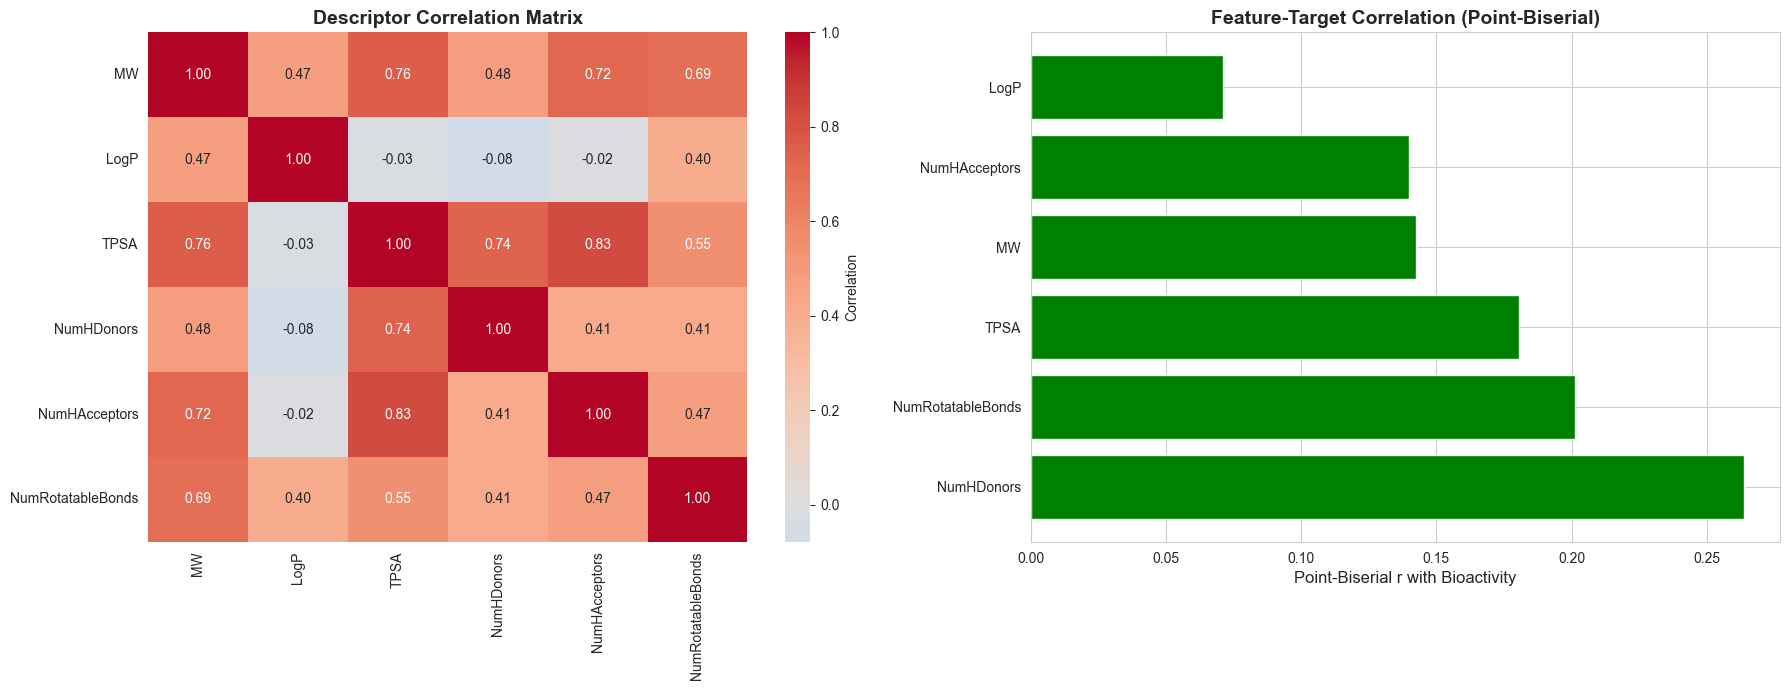


3. FEATURE-TARGET CORRELATION ANALYSIS (Point-Biserial)
--------------------------------------------------------------------------------
       Descriptor     r_pb      p-value  Abs_Corr
       NumHDonors 0.263908 3.277952e-88  0.263908
NumRotatableBonds 0.201290 2.512306e-51  0.201290
             TPSA 0.180449 1.972172e-41  0.180449
               MW 0.142351 2.889664e-26  0.142351
    NumHAcceptors 0.139936 1.984297e-25  0.139936
             LogP 0.071255 1.243172e-07  0.071255

4. MANN-WHITNEY U TEST (Active vs Inactive)
--------------------------------------------------------------------------------
       Descriptor  U-statistic      p-value  Rank_Biserial_r Effect_Size Significant
       NumHDonors    3481110.0 4.202633e-96           0.3779      medium         Yes
             TPSA    3337500.5 8.446275e-64           0.3211      medium         Yes
               MW    3249526.5 4.416707e-51           0.2862       small         Yes
NumRotatableBonds    3233823.5 2.306476e-49   

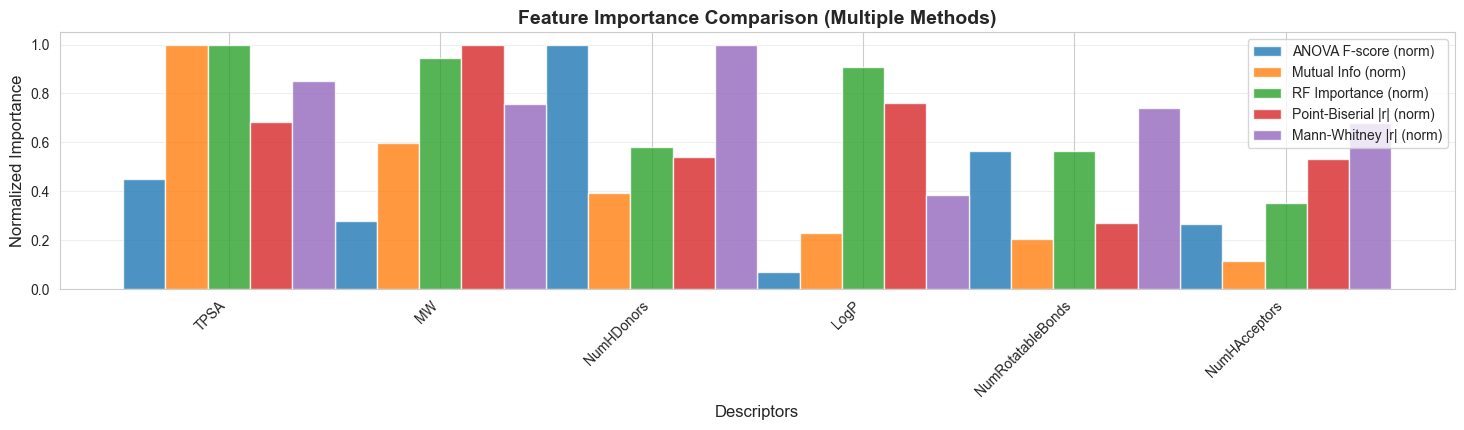


RECOMMENDATIONS FOR FEATURE SELECTION

✓ TOP FEATURES RANKING (by average rank):

✓ TOP FEATURES RANKING (by average rank):
   1. TPSA
   2. MW
   3. NumHDonors
   4. LogP
   5. NumRotatableBonds
   6. NumHAcceptors

⚠️ CONSIDER REMOVING (high multicollinearity):
   - NumHAcceptors (corr with TPSA: 0.826)

⚠️ LOW IMPORTANCE FEATURES (consider removing):

⚠️ LOW IMPORTANCE FEATURES (consider removing):
   - LogP
   - NumRotatableBonds
   - NumHAcceptors

SUGGESTED FINAL FEATURE SET:

Recommended 3 descriptors:
   1. TPSA (rank: 2.00)
   2. MW (rank: 2.40)
   3. NumHDonors (rank: 2.60)

   1. TPSA (rank: 2.00)
   2. MW (rank: 2.40)
   3. NumHDonors (rank: 2.60)



In [28]:
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
import warnings

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*80)
print("COMPREHENSIVE STATISTICAL ANALYSIS OF MOLECULAR DESCRIPTORS")
print("="*80)

# 1. DESCRIPTIVE STATISTICS
print("\n1. DESCRIPTIVE STATISTICS BY BIOACTIVITY CLASS")
print("-"*80)
desc_stats = df.groupby('bioactivity')[descriptors].agg(['mean', 'std', 'median'])
print(desc_stats)

# 2. CORRELATION ANALYSIS
print("\n2. CORRELATION MATRIX OF DESCRIPTORS")
print("-"*80)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Correlation heatmap
corr_matrix = df[descriptors].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Descriptor Correlation Matrix', fontsize=14, fontweight='bold')

# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\n⚠️ Highly Correlated Pairs (|r| > 0.8) - Consider removing one:")
    print(high_corr_df.to_string(index=False))

# Feature-Target correlation
# Point-Biserial is used (not Pearson) because bioactivity is binary (0/1).
# Point-Biserial = Pearson applied to a binary variable with the correct p-value.
from scipy.stats import pointbiserialr
target_corr = []
for desc in descriptors:
    r_pb, pval = pointbiserialr(df['bioactivity'], df[desc])
    target_corr.append({'Descriptor': desc, 'r_pb': r_pb, 'p-value': pval})

target_corr_df = pd.DataFrame(target_corr).sort_values('r_pb', key=abs, ascending=False)
target_corr_df['Abs_Corr'] = target_corr_df['r_pb'].abs()

# Plot feature-target correlation
axes[1].barh(target_corr_df['Descriptor'], target_corr_df['r_pb'], 
             color=['green' if x > 0 else 'red' for x in target_corr_df['r_pb']])
axes[1].set_xlabel('Point-Biserial r with Bioactivity', fontsize=12)
axes[1].set_title('Feature-Target Correlation (Point-Biserial)', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('descriptor_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n3. FEATURE-TARGET CORRELATION ANALYSIS (Point-Biserial)")
print("-"*80)
print(target_corr_df.to_string(index=False))

# 3. STATISTICAL TESTS (Mann-Whitney U for non-parametric comparison)
print("\n4. MANN-WHITNEY U TEST (Active vs Inactive)")
print("-"*80)
statistical_tests = []
for desc in descriptors:
    # Slice per-descriptor inside the loop — each feature gets its own groups
    active   = df[df['bioactivity'] == 1][desc].dropna()
    inactive = df[df['bioactivity'] == 0][desc].dropna()

    u_stat, pval = mannwhitneyu(active, inactive, alternative='two-sided')
    # Rank-biserial r is the correct effect size for Mann-Whitney U.
    # Cohen's d is paired with the t-test (parametric); using it here would be
    # a methodological inconsistency in a non-parametric pipeline.
    n1, n2 = len(active), len(inactive)
    r_rb = abs(1 - (2 * u_stat) / (n1 * n2))
    eff_label = 'large' if r_rb > 0.5 else ('medium' if r_rb > 0.3 else 'small')

    statistical_tests.append({
        'Descriptor': desc,
        'U-statistic': u_stat,
        'p-value': pval,
        'Rank_Biserial_r': round(r_rb, 4),
        'Effect_Size': eff_label,
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

stat_test_df = pd.DataFrame(statistical_tests).sort_values('p-value')
print(stat_test_df.to_string(index=False))

# 4. FEATURE IMPORTANCE ANALYSIS
print("\n5. FEATURE IMPORTANCE ANALYSIS (Borda Count across 5 methods)")
print("-"*80)

X = df[descriptors].values
y = df['bioactivity'].values

# ANOVA F-test
f_scores, f_pvalues = f_classif(X, y)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = rf.feature_importances_

# Align stat_test_df to the original descriptor order so index matches
stat_test_aligned = stat_test_df.set_index('Descriptor').loc[descriptors]

# Combine all importance scores — now including Mann-Whitney rank-biserial r
# as the 5th method (non-parametric, distribution-free effect size)
importance_df = pd.DataFrame({
    'Descriptor':        descriptors,
    'ANOVA_F':           f_scores,
    'ANOVA_p':           f_pvalues,
    'Mutual_Info':       mi_scores,
    'RF_Importance':     rf_importance,
    'Point_Biserial_r':  target_corr_df['Abs_Corr'].values,  # already |r| from abs()
    'MannWhitney_r':     stat_test_aligned['Rank_Biserial_r'].values,
})

# For correlation-based scores, scientific relevance is determined by MAGNITUDE,
# not sign. A feature with r_pb = -0.8 (higher values → inactive) is equally
# discriminative as r_pb = +0.8 (higher values → active).
# Ranking on the raw signed value would incorrectly penalise strong negative
# correlations. We therefore rank on |r| for both correlation measures.
#
# Note: Point_Biserial_r is already stored as Abs_Corr (absolute value).
#       MannWhitney_r from abs(1 - 2U/n1n2) is always ≥ 0 by construction,
#       but we apply abs() defensively for correctness.
importance_df['|Point_Biserial_r|'] = importance_df['Point_Biserial_r'].abs()
importance_df['|MannWhitney_r|']     = importance_df['MannWhitney_r'].abs()

# Borda Count: rank each method 1–N (1 = most important), then average ranks.
# Lower Avg_Rank = consistently important across all methods.
# ANOVA_F, Mutual_Info, RF_Importance are always ≥ 0 — rank directly.
# Correlation columns ranked on their absolute values (see above).
rank_cols = {
    'ANOVA_F':           'ANOVA_F',
    'Mutual_Info':       'Mutual_Info',
    'RF_Importance':     'RF_Importance',
    'Point_Biserial_r':  '|Point_Biserial_r|',
    'MannWhitney_r':     '|MannWhitney_r|',
}
for rank_label, source_col in rank_cols.items():
    importance_df[f'{rank_label}_rank'] = importance_df[source_col].rank(ascending=False)

importance_df['Avg_Rank'] = importance_df[[f'{k}_rank' for k in rank_cols]].mean(axis=1)
importance_df = importance_df.sort_values('Avg_Rank')

print(importance_df[['Descriptor', 'ANOVA_F', 'Mutual_Info', 'RF_Importance',
                      '|Point_Biserial_r|', '|MannWhitney_r|', 'Avg_Rank']].to_string(index=False))

# 5. VISUALIZATIONS
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Feature Importance Comparison
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(descriptors))
width = 0.2

ax1.bar(x_pos - 2*width, importance_df['ANOVA_F'] / importance_df['ANOVA_F'].max(),
        width, label='ANOVA F-score (norm)', alpha=0.8)
ax1.bar(x_pos - 1*width, importance_df['Mutual_Info'] / importance_df['Mutual_Info'].max(),
        width, label='Mutual Info (norm)', alpha=0.8)
ax1.bar(x_pos + 0*width, importance_df['RF_Importance'] / importance_df['RF_Importance'].max(),
        width, label='RF Importance (norm)', alpha=0.8)
ax1.bar(x_pos + 1*width, importance_df['|Point_Biserial_r|'] / importance_df['|Point_Biserial_r|'].max(),
        width, label='Point-Biserial |r| (norm)', alpha=0.8)
ax1.bar(x_pos + 2*width, importance_df['|MannWhitney_r|'] / importance_df['|MannWhitney_r|'].max(),
        width, label='Mann-Whitney |r| (norm)', alpha=0.8)

ax1.set_xlabel('Descriptors', fontsize=12)
ax1.set_ylabel('Normalized Importance', fontsize=12)
ax1.set_title('Feature Importance Comparison (Multiple Methods)', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(importance_df['Descriptor'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2-7: Box plots for top 6 descriptors
# top_descriptors = importance_df.head(6)['Descriptor'].values
# for idx, desc in enumerate(top_descriptors):
#     ax = fig.add_subplot(gs[1 + idx//3, idx%3])
    
#     data_to_plot = [df[df['bioactivity'] == 0][desc], df[df['bioactivity'] == 1][desc]]
#     bp = ax.boxplot(data_to_plot, labels=['Inactive', 'Active'], patch_artist=True)
#     for patch, color in zip(bp['boxes'], colors):
#     # Color boxes
#     colors = ['lightcoral', 'lightgreen']
#     for patch, color in zip(bp['boxes'], colors):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.7)
    
#     # Add mean markers
#     means = [d.mean() for d in data_to_plot]
#     ax.plot([1, 2], means, 'D', color='red', markersize=8, label='Mean')
    
#     ax.set_ylabel(desc, fontsize=11)
#     ax.set_title(f'{desc} Distribution by Class', fontsize=11, fontweight='bold')
#     ax.grid(axis='y', alpha=0.3)
    
#     # Add statistical annotation
#     pval = stat_test_df[stat_test_df['Descriptor'] == desc]['p-value'].values[0]
#     ax.text(0.5, 0.95, f'p={pval:.2e}', transform=ax.transAxes, 
#             ha='center', va='top', fontsize=9, 
#             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('descriptor_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. DISTRIBUTION ANALYSIS
# print("\n6. NORMALITY TESTS (Shapiro-Wilk)")
# print("-"*80)
# normality_tests = []
# for desc in descriptors:
#     stat, pval = shapiro(df[desc].sample(min(5000, len(df)), random_state=42))
#     normality_tests.append({
#         'Descriptor': desc,
#         'W-statistic': stat,
#         'p-value': pval,
#         'Normal': 'Yes' if pval > 0.05 else 'No'
#     })
    
# normality_df = pd.DataFrame(normality_tests)
# print(normality_df.to_string(index=False))

# 7. FINAL RECOMMENDATIONS
print("\n" + "="*80)
print("RECOMMENDATIONS FOR FEATURE SELECTION")
print("="*80)
print(f"\n✓ TOP FEATURES RANKING (by average rank):")
# Top features by average rank
top_features = importance_df.head(13)['Descriptor'].tolist()
print(f"\n✓ TOP FEATURES RANKING (by average rank):")
for i, feat in enumerate(top_features, 1):
    print(f"   {i}. {feat}")

# Features to consider removing (high correlation)
if high_corr_pairs:
    print(f"\n⚠️ CONSIDER REMOVING (high multicollinearity):")
    for pair in high_corr_pairs:
        # Keep the one with higher importance
        feat1_rank = importance_df[importance_df['Descriptor'] == pair['Feature1']]['Avg_Rank'].values[0]
        feat2_rank = importance_df[importance_df['Descriptor'] == pair['Feature2']]['Avg_Rank'].values[0]
        remove = pair['Feature2'] if feat1_rank < feat2_rank else pair['Feature1']
        print(f"   - {remove} (corr with {pair['Feature1'] if remove == pair['Feature2'] else pair['Feature2']}: {pair['Correlation']:.3f})")
print(f"\n⚠️ LOW IMPORTANCE FEATURES (consider removing):")
# Low importance features
low_importance = importance_df.tail(3)['Descriptor'].tolist()
print(f"\n⚠️ LOW IMPORTANCE FEATURES (consider removing):")
for feat in low_importance:
    print(f"   - {feat}")

print("\n" + "="*80)
print("SUGGESTED FINAL FEATURE SET:")
print("="*80)

# Remove highly correlated and low importance
suggested_features = [f for f in top_features if f not in low_importance]
if high_corr_pairs:
    for pair in high_corr_pairs:
        feat1_rank = importance_df[importance_df['Descriptor'] == pair['Feature1']]['Avg_Rank'].values[0]
        feat2_rank = importance_df[importance_df['Descriptor'] == pair['Feature2']]['Avg_Rank'].values[0]
        remove = pair['Feature2'] if feat1_rank < feat2_rank else pair['Feature1']
        if remove in suggested_features:
            suggested_features.remove(remove)


print(f"\nRecommended {len(suggested_features)} descriptors:")
for i, feat in enumerate(suggested_features, 1):
    feat_rank = importance_df[importance_df['Descriptor'] == feat]['Avg_Rank'].values[0]
    print(f"   {i}. {feat} (rank: {feat_rank:.2f})")
print("\n" + "="*80)

for i, feat in enumerate(suggested_features, 1):


    rank = importance_df[importance_df['Descriptor'] == feat]['Avg_Rank'].values[0]
    print(f"   {i}. {feat} (rank: {rank:.2f})")
print("\n" + "="*80)

In [29]:
df.columns

Index(['canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors',
       'bioactivity', 'TPSA', 'NumRotatableBonds'],
      dtype='object')

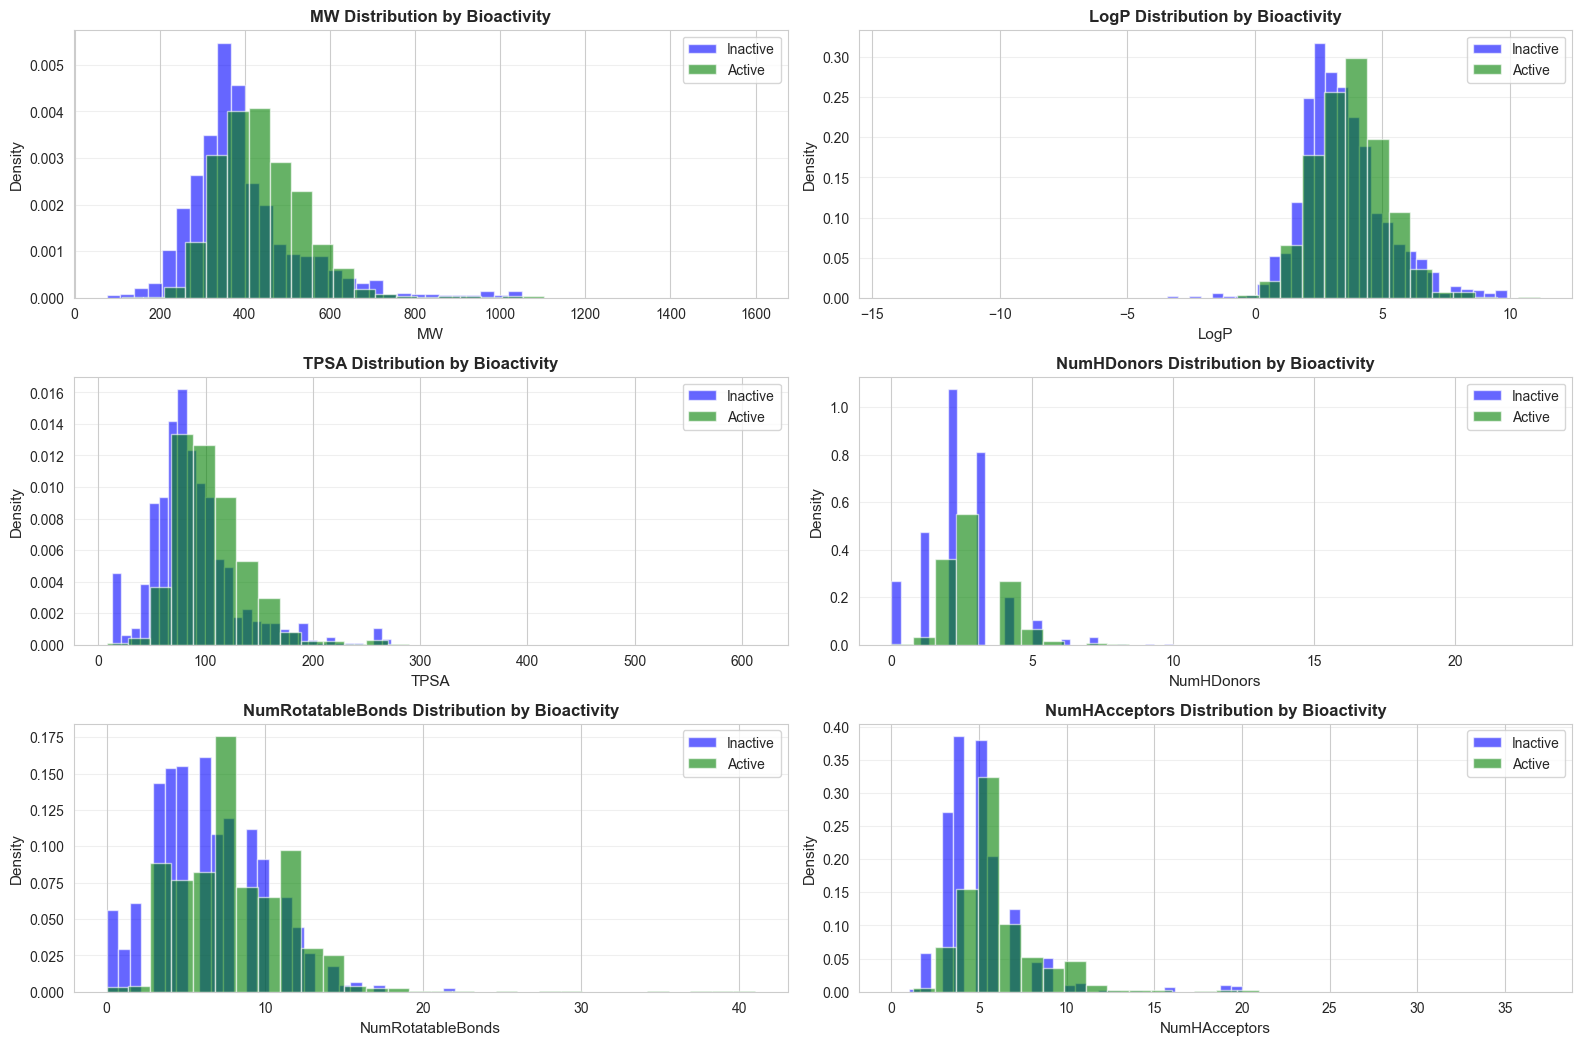

In [31]:
# Generate distribution plots for selected features
selected_features = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumRotatableBonds', 'NumHAcceptors']

fig, axes = plt.subplots(7, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, feature in enumerate(selected_features):
    ax = axes[idx]
    
    # Plot distributions for both classes
    df[df['bioactivity'] == 0][feature].hist(ax=ax, bins=30, alpha=0.6, color='blue', label='Inactive', density=True)
    df[df['bioactivity'] == 1][feature].hist(ax=ax, bins=30, alpha=0.6, color='green', label='Active', density=True)
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{feature} Distribution by Bioactivity', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for idx in range(len(selected_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
df['bioactivity'].value_counts()

bioactivity
1    4326
0    1168
Name: count, dtype: int64